# <font color='056938'> **Dashboard**


## <font color='8EC044'> **1. Preparación**

### **1.1. Importar librerías**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

### **1.2. Cargar las bases de datos**

In [2]:
!gdown 1xlGdiwrhF7iugj1ZrD5jj0rzZxys8XTi
!gdown 1myGeeZEn6tE1NHTWb3dgxLTUwwrq4PAA
!gdown 19ATlHVlt-N8pGdg9xgDADRzICEziCg6d
homicidio = pd.read_csv('homicidio.csv')
hurto = pd.read_csv('hurto_a_persona.csv')
extorsion = pd.read_csv('extorsion.csv')

Downloading...
From: https://drive.google.com/uc?id=1xlGdiwrhF7iugj1ZrD5jj0rzZxys8XTi
To: /content/homicidio.csv
100% 7.07M/7.07M [00:00<00:00, 81.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1myGeeZEn6tE1NHTWb3dgxLTUwwrq4PAA
From (redirected): https://drive.google.com/uc?id=1myGeeZEn6tE1NHTWb3dgxLTUwwrq4PAA&confirm=t&uuid=860c6532-e5d5-4388-974a-bc61a6aa12e4
To: /content/hurto_a_persona.csv
100% 124M/124M [00:00<00:00, 135MB/s]
Downloading...
From: https://drive.google.com/uc?id=19ATlHVlt-N8pGdg9xgDADRzICEziCg6d
To: /content/extorsion.csv
100% 2.43M/2.43M [00:00<00:00, 146MB/s]


/tmp/ipykernel_1752/1250777896.py:5: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  hurto = pd.read_csv('hurto_a_persona.csv')


### **1.3. Exploración de las bases de datos**

In [3]:
# ESTANDARIZAR EL FORMATO DE DATOS FALTANTES
homicidio = homicidio.replace(['Sin dato', 'SIN DATO'], np.nan, regex=True)
hurto = hurto.replace(['Sin dato', 'SIN DATO'], np.nan, regex=True)
extorsion = extorsion.replace(['Sin dato', 'SIN DATO'], np.nan, regex=True)

# UNIÓN DE LAS 3 BASES DE DATOS
df = pd.concat([homicidio, hurto, extorsion], ignore_index=True)
# DEFINIR LA LISTA DE LAS BASES DE DATOS Y SUS RESPECTIVOS NOMBRES
lista_dfs = [('UNIDO', df), ('homicidio', homicidio), ('hurto', hurto), ('extorsion', extorsion)]

# IMPRIMIR INFORMACIÓN
for nombre, dataframe in lista_dfs:
    valores_faltantes = dataframe.isnull().sum()                                           # Contar valores faltantes
    num_filas, num_columnas = dataframe.shape                                              # Obtener número de filas y columnas

    print("\033[1m" + f"INFORMACIÓN DEL DATAFRAME '{nombre}'" + "\033[0m")
    print(f"Número de filas: {num_filas}")
    print(f"Número de columnas: {num_columnas}")
    print("Valores faltantes por columna:")
    print(valores_faltantes)
    print("\n")

/tmp/ipykernel_1752/2887485448.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  homicidio = homicidio.replace(['Sin dato', 'SIN DATO'], np.nan, regex=True)
/tmp/ipykernel_1752/2887485448.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hurto = hurto.replace(['Sin dato', 'SIN DATO'], np.nan, regex=True)
/tmp/ipykernel_1752/2887485448.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To op

INFORMACIÓN DEL DATAFRAME 'UNIDO'
Número de filas: 352676
Número de columnas: 36
Valores faltantes por columna:
fecha_hecho                 0
cantidad                    0
latitud                 44901
longitud                44901
sexo                     2319
edad                        0
estado_civil            51047
grupo_actor            346254
actividad_delictiva    352676
parentesco             352294
ocupacion              340113
discapacidad           352676
grupo_especial         351854
medio_transporte        31407
nivel_academico        344833
testigo                352676
conducta                    0
modalidad               11695
caracterizacion        352676
conducta_especial      254925
arma_medio              35828
articulo_penal         352676
categoria_penal        352676
nombre_barrio            7188
codigo_barrio            7188
codigo_comuna            6795
lugar                   16611
sede_receptora          31731
bien                    68867
categoria_bien    

In [4]:
df["conducta"].unique()

array(['Homicidio', 'Hurto a persona', 'Extorsión'], dtype=object)

In [5]:
df.tail(30)

,fecha_hecho,cantidad,latitud,longitud,sexo,edad,estado_civil,grupo_actor,actividad_delictiva,parentesco,...,lugar,sede_receptora,bien,categoria_bien,grupo_bien,modelo,color,permiso,unidad_medida,fecha_ingestion
352646,2023-11-07T11:00:00.000-05:00,1.0,NaN,NaN,Mujer,32,NaN,Delincuencia,NaN,NaN,...,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-06T04:06:28.000-05:00
352647,2023-11-07T11:30:00.000-05:00,1.0,NaN,NaN,Mujer,32,NaN,Delincuencia,NaN,NaN,...,Residencia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-06T04:06:28.000-05:00
352648,2023-11-07T17:00:00.000-05:00,1.0,NaN,NaN,Hombre,30,NaN,Delincuencia,NaN,NaN,...,Cárcel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-06T04:06:28.000-05:00
352649,2023-11-07T23:01:00.000-05:00,1.0,NaN,NaN,Hombre,29,NaN,Delincuencia,NaN,NaN,...,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-06T04:06:28.000-05:00
352650,2023-11-08T00:00:00.000-05:00,1.0,NaN,NaN,Hombre,28,NaN,Delincuencia,NaN,NaN,...,Café internet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-06T04:06:28.000-05:00
352651,2023-11-08T13:24:00.000-05:00,1.0,NaN,NaN,Hombre,25,NaN,Delincuencia,NaN,NaN,...,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-06T04:06:28.000-05:00
352652,2023-11-08T14:30:00.000-05:00,1.0,NaN,NaN,Hombre,23,NaN,Delincuencia,NaN,NaN,...,"Hotel, motel y hostal",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-06T04:06:28.000-05:00
352653,2023-11-09T14:00:00.000-05:00,1.0,NaN,NaN,Mujer,20,NaN,Delincuencia,NaN,NaN,...,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-06T04:06:28.000-05:00
352654,2023-11-09T14:00:00.000-05:00,1.0,NaN,NaN,Hombre,64,NaN,Delincuencia,NaN,NaN,...,Estación del Metro plus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-06T04:06:28.000-05:00
352655,2023-11-09T16:27:00.000-05:00,1.0,NaN,NaN,Hombre,46,NaN,Delincuencia,NaN,NaN,...,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-06T04:06:28.000-05:00


## <font color='8EC044'> **2. Preprocesamiento de la base de datos**



### **2.1. Redefinición de variables**



Primero, se hará cambios en los nombres de las columnas para que sean más fáciles de comprender

In [6]:
df = df.rename(columns={'conducta': 'tipo_delito'})

In [7]:
df['latitud'] = df['latitud'].round(3)
df['longitud'] = df['longitud'].round(3)

La columna `fecha_hecho` es complicada de leer. Así pues, se divide en dos columnas nuevas, una para la fecha y otra para la hora.


In [8]:
# CONVERTIR LA COLUMNA 'fecha_hecho' A FORMATO DATETIME
df['fecha_hecho'] = pd.to_datetime(df['fecha_hecho'], errors='coerce')

# CREAR NUEVAS COLUMNAS 'fecha' y 'hora'
df['fecha_incidente'] = df['fecha_hecho'].dt.date
df['hora_incidente'] = df['fecha_hecho'].dt.time

# ELIMINAR LA ANTIGUA COLUMNA
df = df.drop(columns=['fecha_hecho'])

### **2.2. Eliminación de variables**



Se toma la decisión de eliminar variables que no aportan mucha información: `cantidad` y `fecha_ingestion`

In [9]:
df = df.drop(['cantidad', 'fecha_ingestion'], axis=1)

### **2.3. Categorización de variables**

Se decide categorizar la columna `hora_incidente`



In [10]:
# CREAR UNA FUNCIÓN
def categorizar_hora(hora):
    if time(0, 0) <= hora < time(6, 0):
        return 'Madrugada'
    elif time(6, 0) <= hora < time(12, 0):
        return 'Mañana'
    elif time(12, 0) <= hora < time(18, 0):
        return 'Tarde'
    else:
        return 'Noche'

# APLICAR LA FUNCIÓN
df['tiempo_incidente'] = df['hora_incidente'].apply(categorizar_hora)

### **2.4. Datos duplicados**

Se busca y se elimina los datos duplicados en el dataset

In [11]:
# VERIFICAR LAS FILAS DUPLICADAS
num_duplicados = homicidio.duplicated().sum()
print(f"Número de filas duplicadas en todo el DataFrame: {num_duplicados}")

# ELIMINAR FILAS DUPLICADAS SI EXISTEN
if num_duplicados > 0:
    homicidio = homicidio.drop_duplicates(keep='first')
    print("Duplicados eliminados")
else:
    print("No hay duplicados en el DataFrame")

Número de filas duplicadas en todo el DataFrame: 68
Duplicados eliminados


### **2.5. Datos atípicos**

La única columna con datos numéricos es `edad`. Se verifica la existencia de datos atípicos.

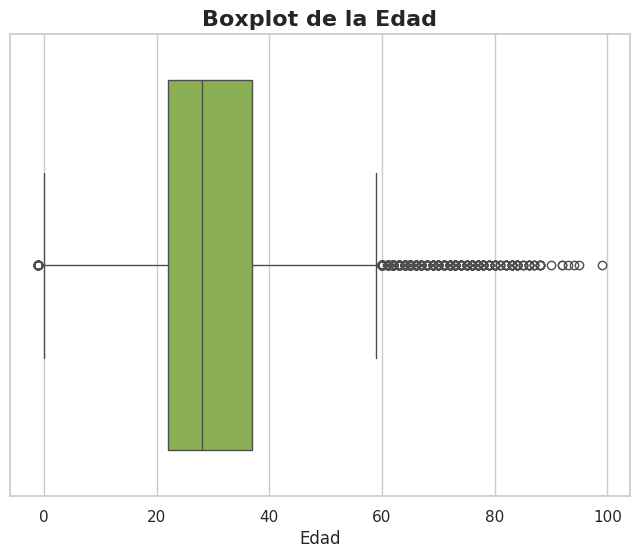

In [12]:
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.boxplot(x='edad', data=homicidio, color='#8EC044')
plt.title('Boxplot de la Edad', fontsize=16, fontweight='bold')
plt.xlabel('Edad', fontsize=12)
plt.show()

Se nota que existen observaciones cuya edad son menores a 0, y se desconoce que representa. Se eliminan estos datos que no pertenecen a un rango de edad coherente

In [13]:
df = df[df['edad'] >= 0]

In [14]:
df

,latitud,longitud,sexo,edad,estado_civil,grupo_actor,actividad_delictiva,parentesco,ocupacion,discapacidad,...,bien,categoria_bien,grupo_bien,modelo,color,permiso,unidad_medida,fecha_incidente,hora_incidente,tiempo_incidente
0,6.257,-75.570,Mujer,50,NaN,NaN,NaN,Desconocido,Comerciante,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-04-23,07:30:00,Mañana
1,6.223,-75.610,Hombre,24,Unión marital de hecho,NaN,NaN,NaN,Vendedor ambulante,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-11,19:51:00,Noche
2,6.262,-75.620,Hombre,34,Casado,NaN,NaN,NaN,Conductor,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-11,21:36:00,Noche
3,6.270,-75.562,Hombre,20,NaN,NaN,NaN,NaN,Oficios varios,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-11,22:03:00,Noche
4,6.236,-75.533,Hombre,34,Unión marital de hecho,NaN,NaN,NaN,Oficial construcción,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-12,17:40:00,Tarde
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352671,NaN,NaN,Hombre,45,NaN,Delincuencia,NaN,NaN,Empleado sector privado,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-11-20,10:00:00,Mañana
352672,NaN,NaN,Mujer,24,NaN,Delincuencia,NaN,NaN,Empleado sector privado,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-11-21,13:00:00,Tarde
352673,NaN,NaN,Mujer,34,NaN,Delincuencia,NaN,NaN,Independiente,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-11-21,23:30:00,Noche
352674,NaN,NaN,Mujer,38,NaN,Delincuencia,NaN,NaN,Empleado sector privado,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-11-23,01:30:00,Madrugada


### **2.6. Datos faltantes**

Se opta por eliminar las columnas donde falten más del 50% de los valores.

Se hacen algunas excepciones porque las variables solo aplican para un crimen específico.

In [15]:
# VALORES FALTANTES ANTES DEL TRATAMIENTO
valores_faltantes_antes = df.isnull().sum()
print("\033[1m" + f"INFORMACIÓN ANTES DE ELIMINAR COLUMNAS" + "\033[0m")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")
print("Valores faltantes por columna:")
print(valores_faltantes_antes)
print("\n")

# CALCULAR EL PORCENTAJE DE VALORES FALTANTES POR COLUMNA
porcentaje_faltantes = df.isnull().mean() * 100
print("\033[1m" + f"PORCENTAJE DE VALORES FALTANTES POR COLUMNA" + "\033[0m")
print(porcentaje_faltantes)
print("\n")

# SELECCIONAR LAS COLUMNAS CON MÁS DEL 50% DE VALORES FALTANTES
columnas_a_eliminar = porcentaje_faltantes[porcentaje_faltantes > 50].index.tolist()

# COLUMNAS EXCEPCIONADAS (NO SE DEBERÍAN ELIMINAR)
excepciones = ['parentesco', 'grupo actor', 'grupo especial', 'color']

# ELIMINAR LAS EXCEPCIONES DE LA LISTA DE COLUMNAS A ELIMINAR
columnas_a_eliminar = [col for col in columnas_a_eliminar if col not in excepciones]

# ELIMINAR LAS COLUMNAS SELECCIONADAS
df = df.drop(columns=columnas_a_eliminar)

# VALORES FALTANTES DESPUÉS DEL TRATAMIENTO
valores_faltantes_despues = df.isnull().sum()
print("\033[1m" + f"INFORMACIÓN DESPUÉS DE ELIMINAR COLUMNAS" + "\033[0m")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")
print("Valores faltantes por columna después de la eliminación:")
print(valores_faltantes_despues)

INFORMACIÓN ANTES DE ELIMINAR COLUMNAS
Número de filas: 347176
Número de columnas: 36
Valores faltantes por columna:
latitud                 43406
longitud                43406
sexo                        8
edad                        0
estado_civil            48046
grupo_actor            341557
actividad_delictiva    347176
parentesco             346796
ocupacion              334749
discapacidad           347176
grupo_especial         346359
medio_transporte        30085
nivel_academico        339334
testigo                347176
tipo_delito                 0
modalidad               11320
caracterizacion        347176
conducta_especial      250772
arma_medio              34527
articulo_penal         347176
categoria_penal        347176
nombre_barrio            6697
codigo_barrio            6697
codigo_comuna            6314
lugar                   15699
sede_receptora          30761
bien                    67206
categoria_bien          57504
grupo_bien              55126
modelo       

Se eliminan algunos datos faltantes, asegurando que su porcentaje no sea significativo, de manera que no afecte la representatividad del conjunto de datos.

In [16]:
# Eliminamos la fila que contenga el valor faltante en la columna 'sexo'
df = df.dropna(subset=['sexo'])
# Eliminamos las filas que contengan valores faltantes en 'nombre_barrio', 'codigo_barrio', 'codigo_comuna' por su complejidad para completar estos datos
df = df.dropna(subset=['nombre_barrio', 'codigo_barrio', 'codigo_comuna'])

## <font color='8EC044'> **3. Dashboard**

Instalación de librerías

In [17]:
!pip install -q dash
!pip install -q dash_core_components
!pip install -q dash_html_components

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 47.8 MB/s eta 0:00:00


Importación de librerías

In [18]:
import pandas as pd
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go

Preparar datos si es necesario

In [19]:
def preparar_datos_delitos(df):

    df['edad_grupo'] = pd.cut(df['edad'], bins=[0, 17, 30, 50, 70, 100],
                              labels=['0-17', '18-30', '31-50', '51-70', '70+'])
    df['fecha_incidente'] = pd.to_datetime(df['fecha_incidente'])
    df['año'] = df['fecha_incidente'].dt.year
    df['dia_mes'] = df['fecha_incidente'].dt.strftime('%d/%m')

    # Calcular frecuencia de delitos por fecha y año
    delitos_por_fecha = df.groupby(['dia_mes', 'año']).size().reset_index(name='frecuencia')
    return df, delitos_por_fecha

### **Funciones**

In [20]:
## PRIMERA PESTAÑA ##

diccionario_comunas = {
    1: "Popular",
    2: "Santa Cruz",
    3: "Manrique",
    4: "Aranjuez",
    5: "Castilla",
    6: "Doce de Octubre",
    7: "Robledo",
    8: "Villa Hermosa",
    9: "Buenos Aires",
    10: "La Candelaria",
    11: "Laureles-Estadio",
    12: "La América",
    13: "San Javier",
    14: "El Poblado",
    15: "Guayabal",
    16: "Belén",
    50: "San Sebastián de Palmitas",
    60: "San Cristóbal",
    70: "Altavista",
    80:  "San Antonio de Prado",
    90: "Santa Elena"
}

def crear_mapa(años):

    df['fecha_incidente'] = pd.to_datetime(df['fecha_incidente'])  # Convertir a datetime

    datos_filtrados = df[df['fecha_incidente'].dt.year.astype(str).isin(años)]  # Filtrar por varios años
    datos_filtrados = datos_filtrados[datos_filtrados['tipo_delito'].str.lower() == 'homicidio']  # Filtrar solo homicidios

    # Filtrar las comunas inválidas
    datos_filtrados = datos_filtrados[datos_filtrados['codigo_comuna'].isin(diccionario_comunas.keys())]

    # Ponemos colores para asignar a los años
    colores = ['#F36273', '#2A9C9D', '#C572A5', '#F7E293', '#FDB078', '#A4E9FF', '#D5ED89', '#5EA8E6', '#FFB8C7', '#AD8589']

    # Iniciamos mapa
    mapa = go.Figure()

    # Trazas para los homicidios por cada año
    for i, year in enumerate(años):
        datos_ano = datos_filtrados[datos_filtrados['fecha_incidente'].dt.year.astype(str) == year]

        mapa.add_trace(go.Scattermapbox(
            lat=datos_ano['latitud'],
            lon=datos_ano['longitud'],
            mode='markers',
            marker=go.scattermapbox.Marker(
                size=12,
                opacity=0.7,
                color=colores[i % len(colores)]
            ),
            text=datos_ano['codigo_comuna'].apply(lambda x: diccionario_comunas.get(x, 'Desconocido')),
            hoverinfo='text',
            name=f'Homicidios {year}'
        ))

    # Layout
    mapa.update_layout(
        mapbox_style="open-street-map",
        autosize=True,
        hovermode='closest',
        showlegend=True,
        height=600
    )

    # Centro del mapa y el nivel de zoom
    if not datos_filtrados.empty:
        mapa.update_mapboxes(
            center=go.layout.mapbox.Center(
                lat=datos_filtrados['latitud'].mean(),
                lon=datos_filtrados['longitud'].mean()
            ),
            zoom=12
        )

    return mapa


## SEGUNDA PESTAÑA

def serie1(tipo_delito, años_seleccionados):

    df['fecha_incidente'] = pd.to_datetime(df['fecha_incidente'])  # Convertimos a formato datetime

    # Filtramos por el tipo de delito y los años seleccionados
    df_filtrado = df[(df['tipo_delito'] == tipo_delito) & (df['fecha_incidente'].dt.year.isin(años_seleccionados))]

    # Columna para año y mes
    df_filtrado['Year'] = df_filtrado['fecha_incidente'].dt.year
    df_filtrado['Mes'] = df_filtrado['fecha_incidente'].dt.month

    # Agrupar por año y mes, contando los delitos
    conteo = df_filtrado.groupby(['Year', 'Mes']).size().reset_index(name='Cantidad')

    # Colores personalizados
    colores_personalizados = ['#F36273', '#2A9C9D', '#C572A5', '#F7E293', '#FDB078', '#A4E9FF', '#D5ED89', '#5EA8E6', '#FFB8C7', '#AD8589']

    # Creamos la gráfica
    fig = px.line(
        conteo,
        x='Mes',
        y='Cantidad',
        color='Year',
        title=f'<b>Cantidad de "{tipo_delito}" por mes</b>',
        labels={'Mes': 'Mes', 'Cantidad': 'Cantidad de delitos', 'Year': 'Año'},
        markers=True,
        color_discrete_sequence=colores_personalizados  # Usar los colores personalizados
    )

    fig.update_traces(mode='lines+markers')
    fig.update_xaxes(
        tickmode='array',
        tickvals=list(range(1, 13)),
        ticktext=['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
    )

    return fig

def serie2(tipo_delito, mes, años_seleccionados):

    df['fecha_incidente'] = pd.to_datetime(df['fecha_incidente'])  # Convertimos a formato datetime

    # Filtramos por el tipo de delito y el mes específico
    df_filtrado = df[(df['tipo_delito'] == tipo_delito) & (df['fecha_incidente'].dt.year.isin(años_seleccionados)) & (df['fecha_incidente'].dt.month == mes)]

    # Columna para año y día
    df_filtrado['Año'] = df_filtrado['fecha_incidente'].dt.year
    df_filtrado['Dia'] = df_filtrado['fecha_incidente'].dt.day

    # Agrupar por año y día, contando los delitos
    conteo = df_filtrado.groupby(['Year', 'Dia']).size().reset_index(name='Cantidad')

    # Colores personalizados
    colores_personalizados = ['#F36273', '#2A9C9D', '#C572A5', '#F7E293', '#FDB078', '#A4E9FF', '#D5ED89', '#5EA8E6', '#FFB8C7', '#AD8589']

    # Creamos la gráfica
    fig = px.line(
        conteo,
        x='Dia',
        y='Cantidad',
        color='Year',
        title=f'<b>Cantidad de "{tipo_delito}" en {["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"][mes-1]}</b>',
        labels={'Dia': 'Día del mes', 'Cantidad': 'Cantidad de delitos', 'Year': 'Año'},
        markers=True,
        color_discrete_sequence=colores_personalizados
    )

    fig.update_traces(mode='lines+markers')
    fig.update_xaxes(
        tickmode='linear',
        tick0=1,
        dtick=1,
        tickvals=list(range(1, 32))  # Ajuste para mostrar todos los días del mes
    )

    return fig

## INCIDENCIA DE EXTORSIONES ##

# Función para generar gráfico de líneas
def generar_grafico_lineas(df, año_seleccionado):

    data = df[df['tipo_delito'] == 'Extorsión']
    data = data[data['año'] == año_seleccionado]
    frecuencia_diaria = data.groupby('fecha_incidente').size().reset_index(name='frecuencia')
    frecuencia_diaria['es_fecha_pago'] = frecuencia_diaria['fecha_incidente'].dt.day.isin([15, 30, 31])

    fig = px.line(
        frecuencia_diaria,
        x='fecha_incidente',
        y='frecuencia',
        title=f"Frecuencia de Extorsiones por Fecha en el Año {año_seleccionado}",
        labels={'fecha_incidente': 'Fecha', 'frecuencia': 'Frecuencia'}
        )

    fig.update_traces(line=dict(color='#2A9C9D'))

    # Agregar puntos para fechas de pago
    fig.add_scatter(
        x=frecuencia_diaria.loc[frecuencia_diaria['es_fecha_pago'], 'fecha_incidente'],
        y=frecuencia_diaria.loc[frecuencia_diaria['es_fecha_pago'], 'frecuencia'],
        mode='markers',
        marker=dict(size=10, color='#F36273', symbol='x'),
        name='Fecha de Pago'
    )

    return fig

# Función para generar gráfico de barras
def generar_grafico_barras(df, sexo_seleccionado):

    data = df.copy()

    if sexo_seleccionado in ['Hombre', 'Mujer']:
        data = data[data['sexo'] == sexo_seleccionado]
        fig = px.bar(
            data_frame=data.groupby('edad_grupo').size().reset_index(name='cantidad'),
            x='edad_grupo',
            y='cantidad',
            labels={'edad_grupo': 'Rango de Edad', 'cantidad': 'Cantidad de Víctimas'},
            color_discrete_sequence=['#5EA8E6'] if sexo_seleccionado == 'Hombre' else ['#FFB8C7']
            )
    else:  # Caso "Todos"
        data = data.groupby(['edad_grupo', 'sexo']).size().reset_index(name='cantidad')
        fig = px.bar(
            data_frame=data,
            x='edad_grupo',


            color='sexo',
            barmode='group',
            title="Cantidad de Víctimas por Rango de Edad (Hombres y Mujeres)",
            labels={'edad_grupo': 'Rango de Edad', 'cantidad': 'Cantidad de Víctimas', 'sexo': 'Sexo'}
            )

    fig.update_layout(
        legend_title_text='Sexo',
        xaxis_title='Rango de Edad',
        yaxis_title='Cantidad de Víctimas')

    return fig

Aplicación de Dash

Que funciones definimos:
1. ¿Cómo se relacionan las modalidades de homicidio con el perfil demográfico de las víctimas (incluyendo edad, sexo y ocupación), y de qué manera estos factores se asocian con los hurtos reportados en Medellín?

2. ¿Existen patrones estacionales en las tasas de homicidio y hurtos durante festividades (como la Feria de las Flores, la Navidad y el Día de la Independencia) en comparación con el resto del año, y cómo se interrelacionan estos crímenes para influir en la percepción de seguridad de los habitantes de Medellín?

3. ¿Cómo varía la incidencia de extorsiones en Medellín según la edad y el sexo de las víctimas, y se observa una mayor frecuencia de estos delitos en las fechas de pago en comparación con otras fechas del año?

In [30]:
# Importar las bibliotecas necesarias
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd

# App
app = Dash(__name__, external_stylesheets=['https://fonts.googleapis.com/css2?family=Montserrat:wght@400;600&display=swap'])

# Cargar y preparar datos
#df = df[0]
df, delitos_por_fecha = preparar_datos_delitos(df)

# Opciones para dropdowns
genero_opciones = [{'label': sexo, 'value': sexo} for sexo in df['sexo'].dropna().unique()] + [{'label': 'Todos', 'value': 'Todos'}]
año_opciones = [{'label': str(año), 'value': año} for año in sorted(df['año'].unique())]

# Diseño de la Aplicación
app.layout = html.Div(
    style={'fontFamily': 'Montserrat', 'margin': '0 auto', 'padding': '20px', 'maxWidth': '1200px', 'backgroundColor': '#f8f9fa'},
    children=[
        # Título principal
        html.H1('ANÁLISIS DE DELITOS EN MEDELLÍN', style={'textAlign': 'center', 'color': '#2b580c', 'fontWeight': 'bold', 'marginBottom': '10px'}),

        # Introducción
        html.Div(
            children='''Este dashboard analiza distintos aspectos relacionados con los delitos reportados en Medellín. Aquí encontrarás información sobre hurtos, homicidios y extorsiones, además de un análisis de patrones estacionales y demográficos.''',
            style={'textAlign': 'center', 'marginBottom': '20px', 'color': '#555'}
        ),

        # Pestañas de navegación
        dcc.Tabs(
            style={'border': '1px solid #ddd', 'boxShadow': '2px 2px 8px rgba(0, 0, 0, 0.1)'},
            children=[

                # Pestaña 1: Homicidios en el mapa
                dcc.Tab(
                    label='Homicidios en el mapa',
                    style={'fontWeight': '600'},
                    selected_style={'backgroundColor': '#e9f5e1'},
                    children=[
                        html.Div(
                            style={'flex': '1', 'paddingLeft': '20px'},
                            children=[
                                html.Div(id='pregunta_hurtos', style={'textAlign': 'center', 'color': '#333', 'fontSize': '18px'}),
                                html.P(
                                    "¿Cómo se relacionan las modalidades de homicidio con el perfil de las víctimas de acuerdo al año y comuna, y de qué manera estos factores se asocian con los hurtos reportados en Medellín?",
                                    style={'fontWeight': 'bold', 'lineHeight': '1.6', 'color': '#495057'}
                                ),
                            ]
                        ),
                        html.Div(
                            style={'display': 'flex', 'justifyContent': 'space-between', 'margin': '20px 0'},
                            children=[
                                html.Div(
                                    style={'flex': '1', 'paddingRight': '20px'},
                                    children=[
                                        html.Label('Año:', style={'color': '#2b580c', 'fontWeight': 'bold'}),
                                        dcc.Dropdown(
                                            id='dropdown-year-homicidios', options=[{'label': str(year), 'value': str(year)} for year in range(2003, 2024)],
                                    multi=True,
                                    placeholder="Selecciona..."
                                    ),
                                    html.Div(style={'margin-bottom': '20px'}),
                                    dcc.Graph(id='mapa-homicidios'),
                                        ]),

                        ]
                        ),
                    ]
                ),

                # Pestaña 2: Patrones Estacionales
                dcc.Tab(
                    label='Patrones Estacionales',
                    style={'fontWeight': '600'},
                    selected_style={'backgroundColor': '#e9f5e1'},
                    children=[
                        html.Div(
                            style={'textAlign': 'center', 'paddingBottom': '20px'},
                            children=[
                                html.Div(id='pregunta_estacional', style={'textAlign': 'center', 'color': '#333', 'fontSize': '18px'}),
                                html.P(
                                    "¿Existen patrones estacionales en las tasas de homicidio y hurtos durante festividades (como la Feria de las Flores, la Navidad y el Día de la Independencia) en comparación con el resto del año, y cómo se interrelacionan estos crímenes para influir en la percepción de seguridad de los habitantes de Medellín?",
                                    style={'fontWeight': 'bold', 'lineHeight': '1.6', 'color': '#495057'}
                                ),
                            ]
                        ),

                        # Filtros y Gráficos
                        html.Div(
                            style={'display': 'flex', 'justifyContent': 'space-between'},
                            children=[

                                # Columna 1: Tipo de delito y año
                                html.Div(
                                    style={'flex': '1', 'paddingRight': '20px'},
                                    children=[
                                        html.Label('Tipo de delito:', style={'color': '#2b580c', 'fontWeight': 'bold'}),
                                        dcc.Dropdown(
                                            id='dropdown-tipodelito-serie1',
                                            options=[{'label': 'Homicidio', 'value': 'Homicidio'},
                                                     {'label': 'Hurto a persona', 'value': 'Hurto a persona'},
                                                     {'label': 'Extorsión', 'value': 'Extorsión'}],
                                            value='Homicidio'
                                        ),
                                        html.Label('Año:', style={'color': '#2b580c', 'fontWeight': 'bold'}),
                                        dcc.Dropdown(
                                            id='dropdown-year-serie1',
                                            options=[{'label': str(year), 'value': str(year)} for year in range(2003, 2024)],
                                            multi=True,
                                            placeholder="Selecciona..."
                                        ),
                                        dcc.Graph(id='serie-1'),
                                    ]
                                ),

                                # Columna 2: Tipo de delito, mes y año
                                html.Div(
                                    style={'flex': '1', 'paddingLeft': '20px'},
                                    children=[
                                        html.Label('Tipo de delito:', style={'color': '#2b580c', 'fontWeight': 'bold'}),
                                        dcc.Dropdown(
                                            id='dropdown-tipodelito-serie2',
                                            options=[{'label': 'Homicidio', 'value': 'Homicidio'},
                                                     {'label': 'Hurto a persona', 'value': 'Hurto a persona'},
                                                     {'label': 'Extorsión', 'value': 'Extorsión'}],
                                            value='Homicidio'
                                        ),
                                        html.Label('Mes:', style={'color': '#2b580c', 'fontWeight': 'bold'}),
                                        dcc.Dropdown(
                                            id='dropdown-mes-serie2',
                                            options=[{'label': mes, 'value': str(i + 1)} for i, mes in enumerate(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'])],
                                            value='1'
                                        ),
                                        html.Label('Año:', style={'color': '#2b580c', 'fontWeight': 'bold'}),
                                        dcc.Dropdown(
                                            id='dropdown-year-serie2',
                                            options=[{'label': str(year), 'value': str(year)} for year in range(2003, 2024)],
                                            multi=True,
                                            placeholder="Selecciona..."
                                        ),
                                        dcc.Graph(id='serie-2'),
                                    ]
                                ),
                            ]
                        ),
                    ]
                ),

                # Pestaña 3: Incidencia de Extorsiones
                dcc.Tab(
                    label='Incidencia de Extorsiones',
                    style={'fontWeight': '600'},
                    selected_style={'backgroundColor': '#e9f5e1'},
                    children=[
                        html.Div(
                            style={'flex': '1', 'paddingLeft': '20px'},
                            children=[
                                html.Div(id='pregunta_extorsion', style={'textAlign': 'center', 'color': '#333', 'fontSize': '18px'}),
                                html.P(
                                    "¿Cómo varía la incidencia de extorsiones en Medellín según la edad y el sexo de las víctimas, y se observa una mayor frecuencia de estos delitos en las fechas de pago en comparación con otras fechas del año?",
                                    style={'fontWeight': 'bold', 'lineHeight': '1.6', 'color': '#495057'}
                                ),
                            ]
                        ),

                        # Filtros de sexo y año
                        html.Div(
                            style={'display': 'flex', 'justifyContent': 'space-between', 'margin': '20px 0'},
                            children=[
                                html.Div(
                                    style={'flex': '1', 'paddingRight': '20px'},
                                    children=[
                                        html.Label('Sexo:', style={'color': '#2b580c', 'fontWeight': 'bold'}),
                                        dcc.Dropdown(
                                            id='dropdown-sexo-extorsion',
                                            options=genero_opciones,
                                            value='Todos'
                                        ),
                                        html.Label('Año:', style={'color': '#2b580c', 'fontWeight': 'bold'}),
                                        dcc.Dropdown(
                                            id='dropdown-year-extorsion',
                                            options=año_opciones,
                                            value=año_opciones[0]['value'] if año_opciones else None
                                        ),
                                    ]
                                ),
                            ]
                        ),

                        # Gráficos de extorsiones
                        html.Div(
                            children=[
                                dcc.Graph(id='bar-chart-extorsion'),
                                html.Div(style={'margin-bottom': '20px'}),
                                dcc.Graph(id='line-chart-extorsion')
                            ]
                        ),
                    ]
                ),
            ]
        ),
    ]
)


## CALLBACKS ##

# CALLBACKS DE PRIMERA PESTAÑA: HOMICIDIOS EN EL MAPA
@app.callback(
    Output('mapa-homicidios', 'figure'),
    Input('dropdown-year-homicidios', 'value')
)
def actualizar_mapa(años):

    if not años:  # Si no se seleccionan años, devuelve un mapa vacío
        return go.Figure(layout=go.Layout(
            title="Por favor selecciona uno o más años",
            mapbox=dict(style="open-street-map", center={"lat": 6.2442, "lon": -75.5812}, zoom=10),
            height=600
        ))

    return crear_mapa(años)

# CALLBACKS DE LA SEGUNDA PESTAÑA: PATRONES ESTACIONALES
@app.callback(
    Output('serie-1', 'figure'),
    [Input('dropdown-tipodelito-serie1', 'value'),
     Input('dropdown-year-serie1', 'value')]
)
def update_serie1(tipo_delito, años):
    if isinstance(años, list):
        años = [int(year) for year in años]  # Convertir a entero
    else:
        años = [int(años)]
    fig_serie1 = serie1(tipo_delito, años)
    fig_serie1.update_layout(
        width=600,
        height=400,
    )
    return fig_serie1

@app.callback(
    Output('serie-2', 'figure'),
    [Input('dropdown-tipodelito-serie2', 'value'),
     Input('dropdown-mes-serie2', 'value'),
     Input('dropdown-year-serie2', 'value')]
)
def update_serie2(tipo_delito, mes, años):
    if isinstance(años, list):
        años = [int(year) for year in años]  # Convertir a entero
    else:
        años = [int(años)]
    mes = int(mes)  # Asegurar que el mes sea un entero
    fig_serie2 = serie2(tipo_delito, mes, años)
    fig_serie2.update_layout(
        width=600,
        height=400,
    )
    return fig_serie2

# CALLBACKS PARA LA TERCERA PESTAÑA: INCIDENCIA DE EXTORSIONES
@app.callback(
    Output('bar-chart-extorsion', 'figure'),
    [Input('dropdown-sexo-extorsion', 'value')]
)
def actualizar_grafico_barras_extorsion(sexo_seleccionado):
    return generar_grafico_barras(df, sexo_seleccionado)

@app.callback(
    Output('line-chart-extorsion', 'figure'),
    [Input('dropdown-year-extorsion', 'value')]
)
def actualizar_grafico_lineas_extorsion(año_seleccionado):
    return generar_grafico_lineas(df, año_seleccionado)

# Ejecutar la Aplicación
if __name__ == '__main__':
    app.run(jupyter_mode="inline")


<IPython.core.display.Javascript object>